Train shape: (215257, 128), Val shape: (46127, 128), Test shape: (46127, 128)
Exploring GBDT Learning Rates...


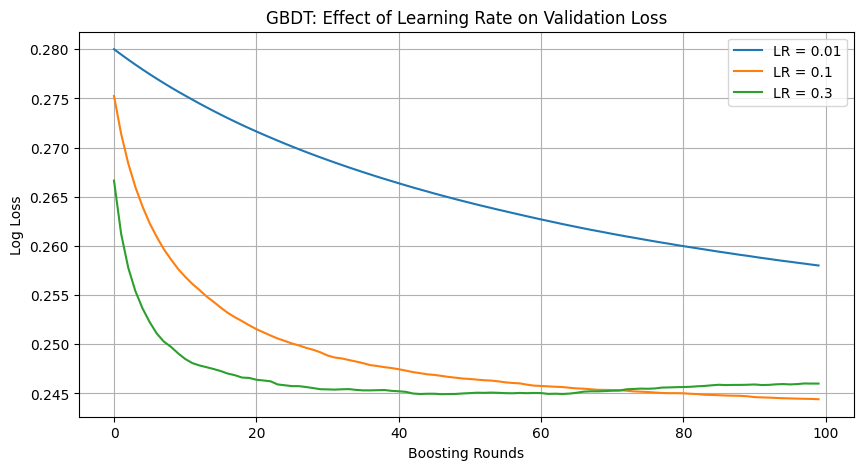


Training Final XGBoost...
[0]	validation_0-logloss:0.27786	validation_1-logloss:0.27783
[50]	validation_0-logloss:0.24811	validation_1-logloss:0.24989
[100]	validation_0-logloss:0.24171	validation_1-logloss:0.24615
[150]	validation_0-logloss:0.23799	validation_1-logloss:0.24473
[200]	validation_0-logloss:0.23504	validation_1-logloss:0.24386
[250]	validation_0-logloss:0.23256	validation_1-logloss:0.24347
[300]	validation_0-logloss:0.23017	validation_1-logloss:0.24330
[350]	validation_0-logloss:0.22808	validation_1-logloss:0.24318
[381]	validation_0-logloss:0.22672	validation_1-logloss:0.24318

Exploring MLP Architectures...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


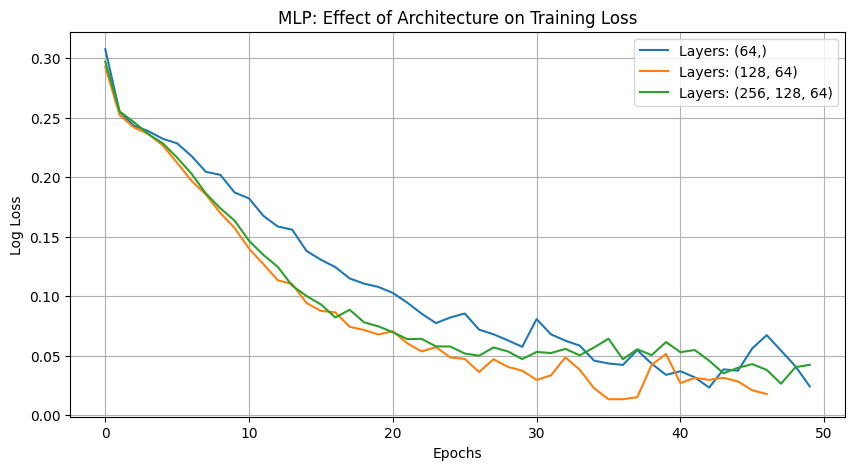


Training Final MLP (CPU)...


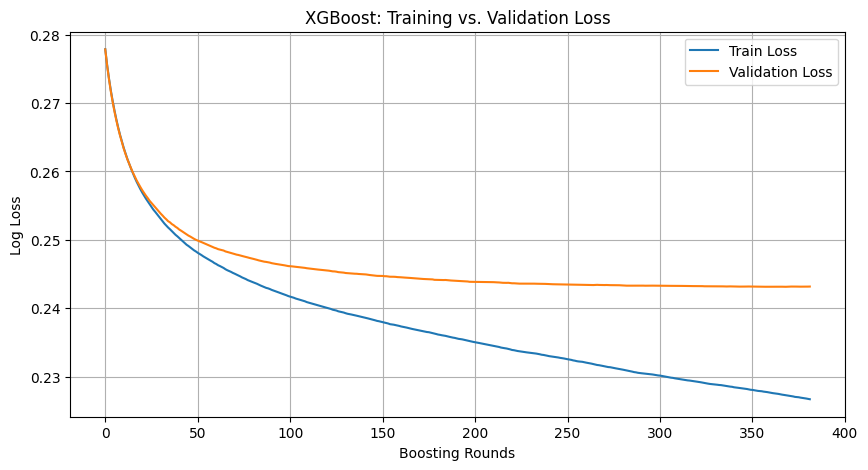

<Figure size 1200x800 with 0 Axes>

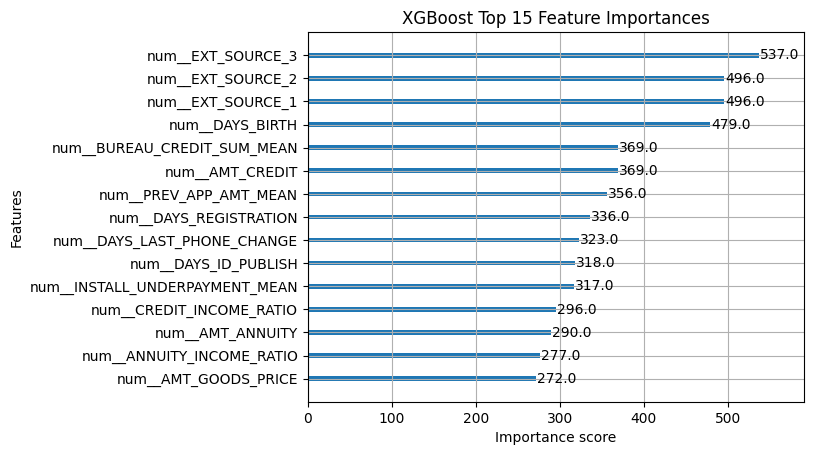

<Figure size 1000x600 with 0 Axes>

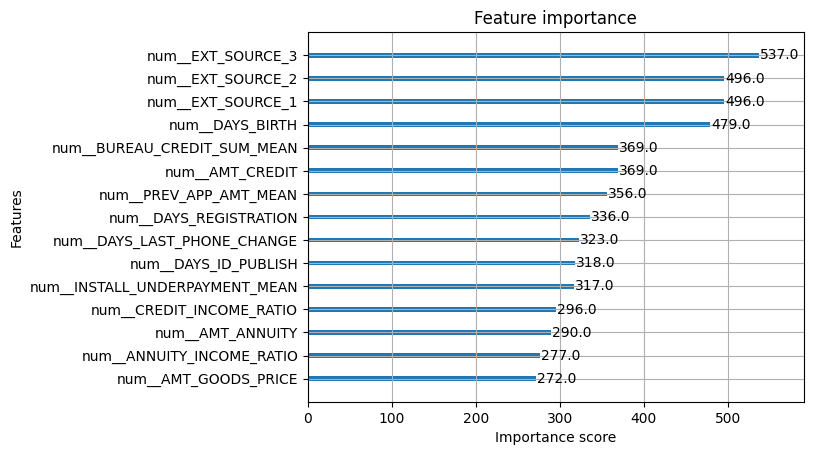

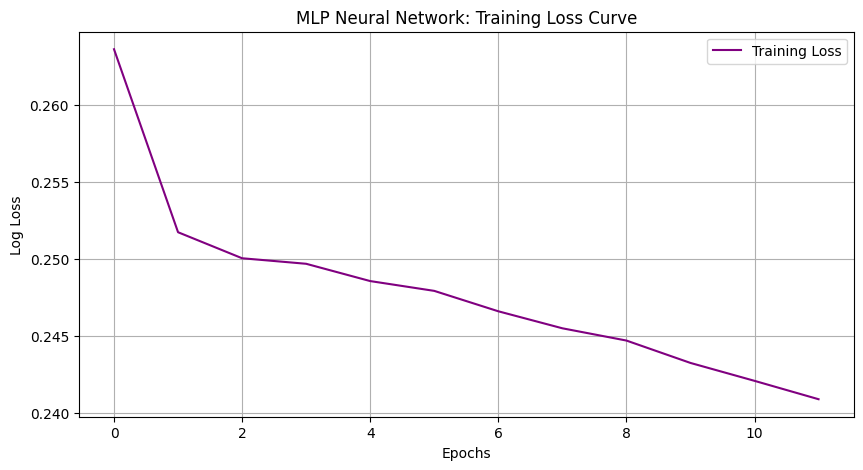


Running Randomized Search for MLP (Subsampled)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


RandomizedSearchCV(cv=2, estimator=MLPClassifier(max_iter=100, random_state=42),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'activation': ['relu', 'tanh'],
                                        'hidden_layer_sizes': [(64,),
                                                               (128, 64)],
                                        'learning_rate_init': [0.001, 0.01]})

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# ==========================================
# 1. Load Data
# ==========================================
# Note: Ensure these files are in your current directory
df = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')
previous_application = pd.read_csv('previous_application.csv')
installments_payments = pd.read_csv('installments_payments.csv')

# ==========================================
# 2. Feature Engineering
# ==========================================
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_CURR', 'count'),
    BUREAU_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean')
).reset_index()

prev_app_agg = previous_application.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_CURR', 'count'),
    PREV_APP_AMT_MEAN=('AMT_APPLICATION', 'mean')
).reset_index()

installments_payments['PAYMENT_DIFFERENCE'] = installments_payments['AMT_INSTALMENT'] - installments_payments['AMT_PAYMENT']
installments_agg = installments_payments.groupby('SK_ID_CURR').agg(
    INSTALL_UNDERPAYMENT_MEAN=('PAYMENT_DIFFERENCE', 'mean')
).reset_index()

# Merge into main dataframe
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left') \
       .merge(prev_app_agg, on='SK_ID_CURR', how='left') \
       .merge(installments_agg, on='SK_ID_CURR', how='left')

# Fill missing counts with 0 (assumes no record means no history)
df['BUREAU_LOAN_COUNT'] = df['BUREAU_LOAN_COUNT'].fillna(0)
df['PREV_APP_COUNT'] = df['PREV_APP_COUNT'].fillna(0)

# Custom Financial Ratios
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Handle DAYS_EMPLOYED anomaly (365243) before calculating ratio
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

# Drop ID column
df = df.drop(columns=['SK_ID_CURR'])

# ==========================================
# 3. Separate Features and Target
# ==========================================
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# ==========================================
# 4. Split Data (70/15/15) - Stratified to handle class imbalance
# ==========================================
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), stratify=y_temp, random_state=42)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

# ==========================================
# 5. Identify Columns
# ==========================================
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# ==========================================
# 6. Build Transformers (Preventing Data Leakage)
# ==========================================
# GBDT Transformer
num_transformer_gbdt = SimpleImputer(strategy='median')
cat_transformer_gbdt = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_gbdt = ColumnTransformer(transformers=[
    ('num', num_transformer_gbdt, num_cols),
    ('cat', cat_transformer_gbdt, cat_cols)
]).set_output(transform="pandas")

# MLP Transformer (Requires Scaling)
num_transformer_mlp = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer_mlp = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('scaler', StandardScaler())
])

preprocessor_mlp = ColumnTransformer(transformers=[
    ('num', num_transformer_mlp, num_cols),
    ('cat', cat_transformer_mlp, cat_cols)
]).set_output(transform="pandas")

# ==========================================
# 7. Apply Transformations
# ==========================================
X_train_gbdt = preprocessor_gbdt.fit_transform(X_train)
X_val_gbdt = preprocessor_gbdt.transform(X_val)
X_test_gbdt = preprocessor_gbdt.transform(X_test)

X_train_mlp = preprocessor_mlp.fit_transform(X_train)
X_val_mlp = preprocessor_mlp.transform(X_val)
X_test_mlp = preprocessor_mlp.transform(X_test)

# ==========================================
# 8. Gradient Boosted Tree (GBDT)
# ==========================================

# 8a. Exploration: Effect of Learning Rate
learning_rates = [0.01, 0.1, 0.3]
plt.figure(figsize=(10, 5))

print("Exploring GBDT Learning Rates...")
for lr in learning_rates:
    temp_xgb = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=5,
        tree_method='hist',
        device='cuda',
        random_state=42,
        eval_metric="logloss"
    )
    temp_xgb.fit(X_train_gbdt, y_train, eval_set=[(X_val_gbdt, y_val)], verbose=False)
    val_loss = temp_xgb.evals_result()['validation_0']['logloss']
    plt.plot(val_loss, label=f'LR = {lr}')

plt.title('GBDT: Effect of Learning Rate on Validation Loss')
plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.legend(); plt.grid(True); plt.show()

# Final GBDT Model Training
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    device='cuda',
    random_state=42,
    early_stopping_rounds=20,
    eval_metric="logloss"
)

print("\nTraining Final XGBoost...")
start_time = time.time()
xgb_model.fit(X_train_gbdt, y_train, eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)], verbose=50)
gbdt_train_time = time.time() - start_time

# ==========================================
# 9. Multi-Layer Perceptron (MLP)
# ==========================================

# 9a. Exploration: Effect of Network Depth/Width
architectures = [(64,), (128, 64), (256, 128, 64)]
plt.figure(figsize=(10, 5))

print("\nExploring MLP Architectures...")
X_sub, y_sub = X_train_mlp[:20000], y_train[:20000] # Subsampled for speed

for arch in architectures:
    temp_mlp = MLPClassifier(hidden_layer_sizes=arch, activation='relu', learning_rate_init=0.01, max_iter=50, random_state=42)
    temp_mlp.fit(X_sub, y_sub)
    plt.plot(temp_mlp.loss_curve_, label=f'Layers: {arch}')

plt.title('MLP: Effect of Architecture on Training Loss')
plt.xlabel('Epochs'); plt.ylabel('Log Loss'); plt.legend(); plt.grid(True); plt.show()

# Final MLP Model Training
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)

print("\nTraining Final MLP (CPU)...")
start_time = time.time()
mlp_model.fit(X_train_mlp, y_train)
mlp_train_time = time.time() - start_time

# ==========================================
# 10. Visualizations
# ==========================================

# Chart A: XGBoost Training vs Validation Loss
results = xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Loss')
plt.legend()
plt.title('XGBoost: Training vs. Validation Loss')
plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()

# Chart B: MLP Training Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, label='Training Loss', color='purple')
plt.title('MLP Neural Network: Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 10. Randomized Search CV (Hyperparameter Tuning)
# ==========================================
print("\nRunning Randomized Search for MLP (Subsampled)...")
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}
mlp_search = RandomizedSearchCV(MLPClassifier(max_iter=100, random_state=42), mlp_param_grid, n_iter=3, cv=2, n_jobs=-1)
mlp_search.fit(X_train_mlp[:10000], y_train[:10000])
# print(f"Best MLP Parameters Found: {mlp_search.best_params_}")


--- Final Side-by-Side Comparison (Threshold: 0.1) ---


,Accuracy,Precision,Recall,F1-Score,AUC-PR,Train Time (s)
GBDT (XGBoost),0.7639,0.1936,0.6079,0.2936,0.2560,9.47
MLP (Neural Net),0.6759,0.1562,0.6847,0.2544,0.2112,29.25


<Figure size 1000x500 with 0 Axes>

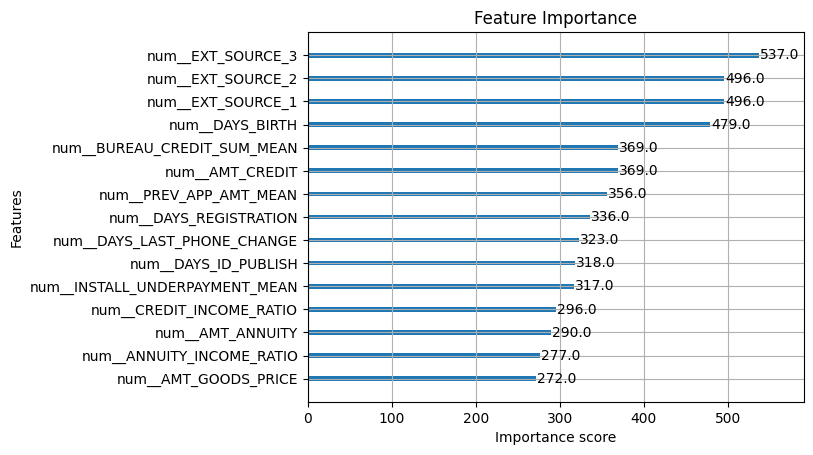

In [ ]:
# ==========================================
# 12. Final Comparison & Evaluation
# ==========================================
CUSTOM_THRESHOLD = 0.10
y_proba_gbdt = xgb_model.predict_proba(X_test_gbdt)[:, 1]
y_proba_mlp = mlp_model.predict_proba(X_test_mlp)[:, 1]

y_pred_gbdt = (y_proba_gbdt >= CUSTOM_THRESHOLD).astype(int)
y_pred_mlp = (y_proba_mlp >= CUSTOM_THRESHOLD).astype(int)

def get_metrics(y_true, y_pred, y_proba, t_time):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-PR': round(average_precision_score(y_true, y_proba), 4),
        'Train Time (s)': round(t_time, 2)
    }

comparison_df = pd.DataFrame([
    get_metrics(y_test, y_pred_gbdt, y_proba_gbdt, gbdt_train_time),
    get_metrics(y_test, y_pred_mlp, y_proba_mlp, mlp_train_time)
], index=['GBDT (XGBoost)', 'MLP (Neural Net)'])

print(f"\n--- Final Side-by-Side Comparison (Threshold: {CUSTOM_THRESHOLD}) ---")
display(comparison_df)

# Chart C: XGBoost Feature Importance
plt.figure(figsize=(10, 5))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=15,
                    title='Feature Importance')
plt.show()